In [1]:
numbers_set = {1}
numbers_list = []
max_number = int(1 * 10 ** 3)
sort_count = 0

def fill_prime_line(prime, prime_line):
    global sort_count

    dim = 0
    while dim < len(prime_line):
        max_prod = 0
        sort = False
        new = True
        for p_line in numbers_list:
            if p_line[dim][0] * prime > max_number:
                break

            for value in p_line[dim]:
                product = value * prime
                if product > max_number:
                    break
                numbers_set.add(product)

                if new:
                    prime_line.append([])
                    new = False
                prime_line[dim + 1].append(product)

                if product < max_prod:
                    sort = True
                max_prod = max(product, max_prod)

        if sort:
            prime_line[dim + 1].sort()
            sort_count += 1
        dim += 1


def add_new_prime(new_prime):
    numbers_set.add(new_prime)
    new_prime_line_dimension = [new_prime]
    new_prime_line = [new_prime_line_dimension]
    numbers_list.append(new_prime_line)

    fill_prime_line(new_prime, new_prime_line)


for n in range(1, max_number + 1):
    if n not in numbers_set:
        # print(len(numbers_list) + 1, n, len(numbers_set), sort_count)
        add_new_prime(n)


# for number_line in numbers_list:
#     print(number_line)
print('n', len(numbers_set), 'p', len(numbers_list), 'sorted', sort_count)


n 1000 p 168 sorted 32


In [2]:
data = numbers_list
result = [[len(inner) for inner in sublist] for sublist in data]

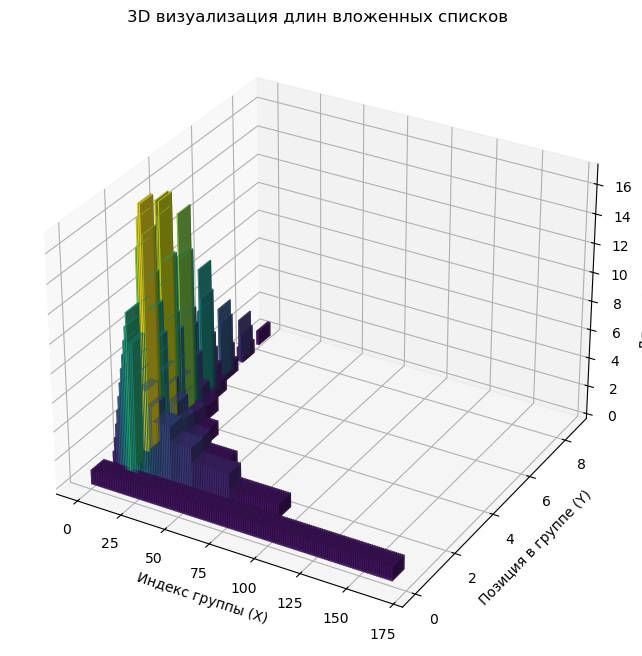

In [4]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Подготовка данных для 3D
x_coords = []
y_coords = []
z_heights = []

for i, sublist in enumerate(data):
    for j, inner_list in enumerate(sublist):
        x_coords.append(i)          # Номер основной группы
        y_coords.append(j)          # Индекс внутри группы
        z_heights.append(len(inner_list)) # Длина списка (высота столбца)

# 2. Настройка графика
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# Параметры столбцов
x = np.array(x_coords)
y = np.array(y_coords)
z = np.zeros_like(x) # Начало столбцов по оси Z (от нуля)
dx = dy = 0.6        # Ширина столбцов

# 3. Отрисовка
# Используем cmap для цветовой индикации высоты
colors = plt.cm.viridis(np.array(z_heights) / max(z_heights))
ax.bar3d(x, y, z, dx, dy, z_heights, color=colors, alpha=0.8)

# Оформление
ax.set_xlabel('Индекс группы (X)')
ax.set_ylabel('Позиция в группе (Y)')
ax.set_zlabel('Длина списка (Z)')
ax.set_title('3D визуализация длин вложенных списков')

plt.show()


In [5]:
from itertools import combinations_with_replacement
from math import prod

def get_prime_combinations(primes, limit):
    results = set()
    
    # Максимально возможная длина комбинации (например, для числа 2 и лимита 100 это 6, т.к. 2^6 < 100)
    # Мы берем с запасом, пока произведение минимального числа не превысит лимит
    max_len = 0
    if primes:
        temp_prod = 1
        min_p = min(primes)
        while temp_prod <= limit:
            temp_prod *= min_p
            max_len += 1

    # Перебираем все возможные длины комбинаций от 1 до max_len
    for r in range(1, max_len + 1):
        for combo in combinations_with_replacement(primes, r):
            p = prod(combo)
            if p <= limit:
                results.add(p)
                
    return sorted(list(results))

# Пример использования:
primes_list = [2, 3, 5]
max_value = 100

combinations = get_prime_combinations(primes_list, max_value)
print(f"Найдено {len(combinations)} чисел: {combinations}")


Найдено 33 чисел: [2, 3, 4, 5, 6, 8, 9, 10, 12, 15, 16, 18, 20, 24, 25, 27, 30, 32, 36, 40, 45, 48, 50, 54, 60, 64, 72, 75, 80, 81, 90, 96, 100]


In [6]:
from itertools import count, takewhile

max_number = 1_000
numbers_set = {1}
primes = []

# Вместо сложной структуры списков используем простую логику решета
for n in range(2, max_number + 1):
    if n not in numbers_set:
        primes.append(n)
        # Генерируем все кратные числа на лету
        # В контексте вашей задачи: добавляем n и все его комбинации с уже найденными
        current_multiples = {n}
        for existing in list(numbers_set):
            prod = existing * n
            while prod <= max_number:
                current_multiples.add(prod)
                prod *= n # Учитываем степени числа
        
        numbers_set.update(current_multiples)

print(f'n: {len(numbers_set)}, p: {len(primes)}')


n: 1000, p: 168


# Вероятность выпадения ровно 500 орлов в серии из 1000 бросков

$P = \frac{1000!}{500! \cdot 500! \cdot 2^{1000}}$
Вероятность выпадения ровно 500 орлов в серии из 1000 бросков $\approx{2.5\%}$

In [35]:
from math import factorial

factorial(1000)

4023872600770937735437024339230039857193748642107146325437999104299385123986290205920442084869694048004799886101971960586316668729948085589013238296699445909974245040870737599188236277271887325197795059509952761208749754624970436014182780946464962910563938874378864873371191810458257836478499770124766328898359557354325131853239584630755574091142624174743493475534286465766116677973966688202912073791438537195882498081268678383745597317461360853795345242215865932019280908782973084313928444032812315586110369768013573042161687476096758713483120254785893207671691324484262361314125087802080002616831510273418279777047846358681701643650241536913982812648102130927612448963599287051149649754199093422215668325720808213331861168115536158365469840467089756029009505376164758477284218896796462449451607653534081989013854424879849599533191017233555566021394503997362807501378376153071277619268490343526252000158885351473316117021039681759215109077880193931781141945452572238655414610628921879602238389714760

In [36]:
factorial(500)**2 * 2**1000

1595191159950403320660121687861646065024682095597540168441706776145713330564058426526734057037053521615270916012981248361733237792405048045414585499135139993408354397740426486576852946439461739263222937928674532998230339075747228919133162989211720894178794520047152826978429927165790127919358821706539833222672300687843776717840589551837523582801250571848652176178202599505716553193962146191925880508955673495455933481741351594224527059937119186717916182213660992106796375294728518351594618101356355534543868210955402224532284996406805331917358148938120410000159334622475946537837327330887075864405387894370213163969934019239710317683095722195028407128900019251933465211796384939450235416890742722475916526570788791941030976845112201004102493164229942417119751193853627233556040205899442992431607851902865340231126269652959070186150620742882730782728758630872528180084720608649486098578163489740869785376762802026866602453949452611958497241161158178861588018833890020960624554443245241580217367278825

In [37]:
factorial(1000) / (factorial(500)**2 * 2**1000)

0.0252250181783608

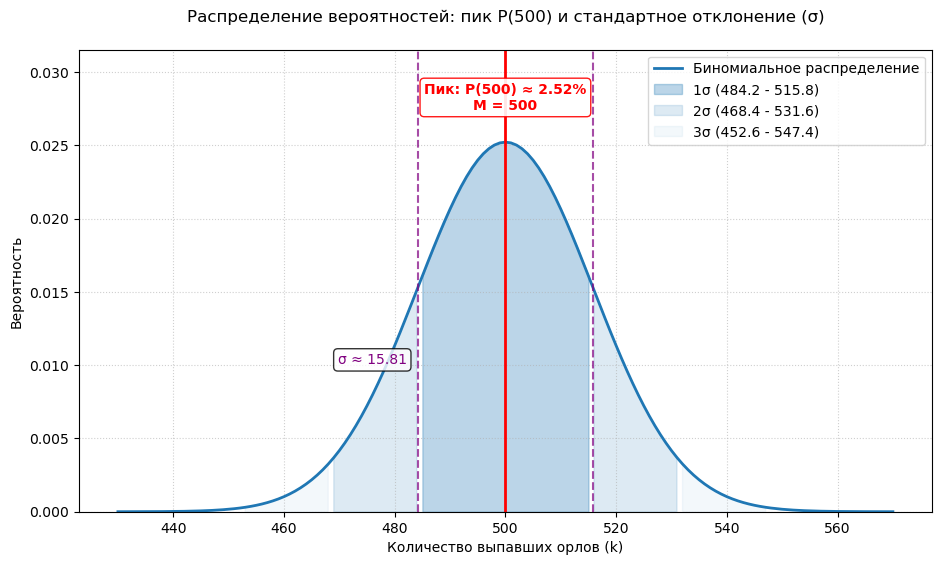

In [38]:
# 4. Создание графика
plt.figure(figsize=(11, 6))  # Немного расширили график
plt.plot(x, y, color="#1f77b4", linewidth=2, label="Биномиальное распределение")

# Подсветка зон 1σ, 2σ и 3σ
plt.fill_between(
    x,
    0,
    y,
    where=((x >= mu - sigma) & (x <= mu + sigma)),
    color="#1f77b4",
    alpha=0.3,
    label=f"1σ ({mu - sigma:.1f} - {mu + sigma:.1f})",
)
plt.fill_between(
    x,
    0,
    y,
    where=(
        ((x >= mu - 2 * sigma) & (x < mu - sigma))
        | ((x > mu + sigma) & (x <= mu + 2 * sigma))
    ),
    color="#1f77b4",
    alpha=0.15,
    label=f"2σ ({mu - 2*sigma:.1f} - {mu + 2*sigma:.1f})",
)
plt.fill_between(
    x,
    0,
    y,
    where=(
        ((x >= mu - 3 * sigma) & (x < mu - 2 * sigma))
        | ((x > mu + 2 * sigma) & (x <= mu + 3 * sigma))
    ),
    color="#1f77b4",
    alpha=0.05,
    label=f"3σ ({mu - 3*sigma:.1f} - {mu + 3*sigma:.1f})",
)

# Вертикальные линии
plt.axvline(
    mu, color="red", linestyle="-", linewidth=2
)  # Убрали label, чтобы не дублировать в легенде
plt.axvline(mu - sigma, color="purple", linestyle="--", alpha=0.7)
plt.axvline(mu + sigma, color="purple", linestyle="--", alpha=0.7)

# ИСПРАВЛЕНО: Плашка теперь строго над пиком и не наезжает на график
plt.text(
    mu,
    p_500 * 1.08,
    f"Пик: P(500) ≈ {p_500*100:.2f}%\nM = {int(mu)}",
    color="red",
    fontsize=10,
    fontweight="bold",
    ha="center",
    va="bottom",  # Выравнивание по центру над точкой
    bbox=dict(facecolor="white", edgecolor="red", alpha=0.9, boxstyle="round"),
)

# Плашка для сигмы чуть смещена влево, чтобы не мешать
plt.text(
    mu - sigma - 2,
    p_500 * 0.4,
    f"σ ≈ {sigma:.2f}",
    color="purple",
    fontsize=10,
    ha="right",
    bbox=dict(facecolor="white", alpha=0.8, boxstyle="round,pad=0.3"),
)

# Оформление графика
plt.title(
    "Распределение вероятностей: пик P(500) и стандартное отклонение (σ)",
    fontsize=12,
    pad=20,
)
plt.xlabel("Количество выпавших орлов (k)", fontsize=10)
plt.ylabel("Вероятность", fontsize=10)
plt.ylim(0, p_500 * 1.25)  # Добавили запас сверху для плашки
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend(loc="upper right")

plt.show()


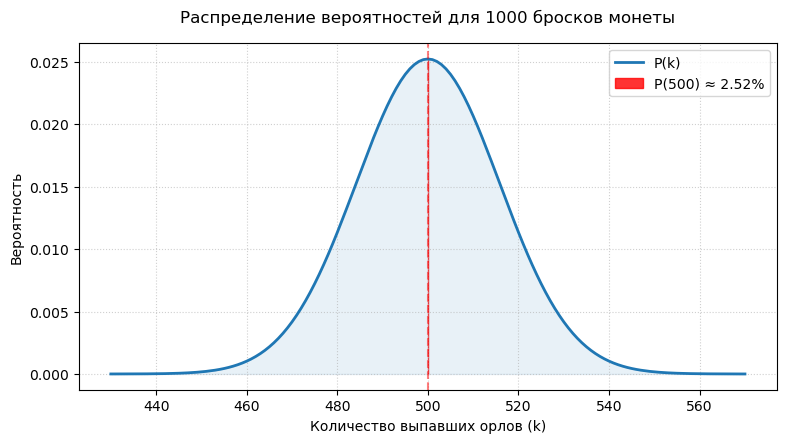

In [31]:
import base64
import io
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import binom

# Параметры задачи
n = 1000  # количество бросков
p = 0.5  # вероятность выпадения орла

# Диапазон количества орлов для отображения на графике (окрестность 500)
x = np.arange(430, 571)
y = binom.pmf(x, n, p)

# Создание графика
plt.figure(figsize=(9, 4.5))
plt.plot(x, y, color="#1f77b4", linewidth=2, label="P(k)")

# Выделение точки 500 красным цветом
plt.fill_between(
    x,
    0,
    y,
    where=(x == 500),
    color="red",
    alpha=0.8,
    label="P(500) ≈ 2.52%",
)
plt.fill_between(x, 0, y, alpha=0.1, color="#1f77b4")

# Оформление осей и сетки
plt.title(
    "Распределение вероятностей для 1000 бросков монеты",
    fontsize=12,
    pad=15,
)
plt.xlabel("Количество выпавших орлов (k)", fontsize=10)
plt.ylabel("Вероятность", fontsize=10)
plt.axvline(500, color="red", linestyle="--", alpha=0.5)
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend(loc="upper right")

# Показ графика
plt.show()


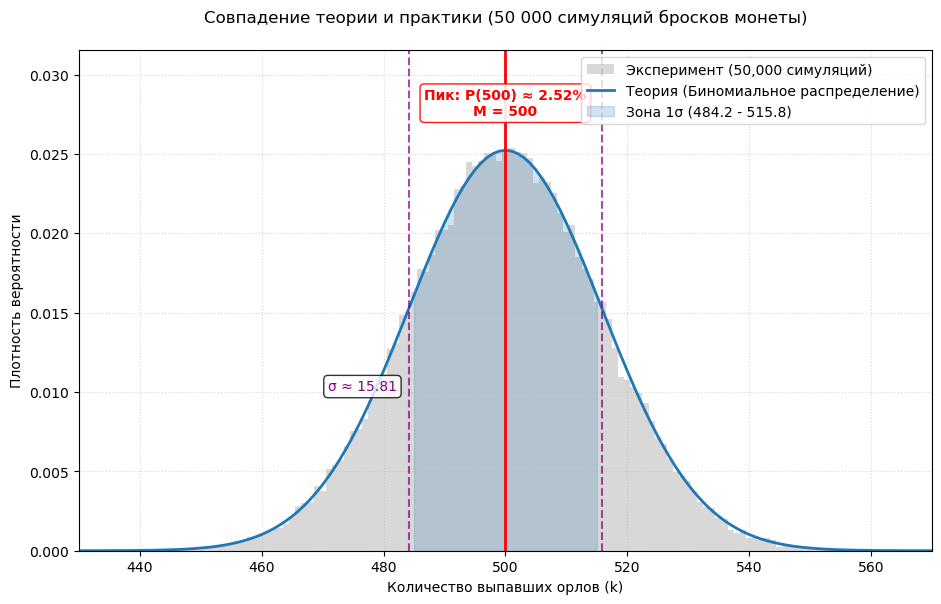

In [39]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import binom

# 1. Параметры задачи
n = 1000  # количество бросков в одной серии
p = 0.5  # вероятность орла
num_simulations = 50000  # количество симуляций (серий)

# 2. Реальное компьютерное моделирование (Монте-Карло)
np.random.seed(42)  # фиксируем сид для воспроизводимости
# Генерируем 50 000 случайных чисел, каждое — результат серии из 1000 бросков
simulated_results = np.random.binomial(n, p, num_simulations)

# 3. Расчет теоретических параметров
mu = n * p  # M = 500
sigma = np.sqrt(n * p * (1 - p))  # Sigma ≈ 15.81
p_500 = binom.pmf(500, n, p)  # Теоретический пик

# Диапазон количества орлов для отображения на графике
x = np.arange(430, 571)
y = binom.pmf(x, n, p)

# 4. Создание графика
plt.figure(figsize=(11, 6.5))

# --- ПРАКТИКА (Экспериментальные данные) ---
# Строим гистограмму реальных исходов. density=True нормирует её в вероятности
plt.hist(
    simulated_results,
    bins=np.arange(430, 572) - 0.5,
    density=True,
    color="#7f7f7f",
    alpha=0.3,
    label=f"Эксперимент ({num_simulations:,} симуляций)",
)

# --- ТЕОРИЯ (Математическое распределение) ---
plt.plot(
    x,
    y,
    color="#1f77b4",
    linewidth=2,
    label="Теория (Биномиальное распределение)",
)

# Подсветка зоны 1 сигмы (математическое ожидание ± отклонение)
plt.fill_between(
    x,
    0,
    y,
    where=((x >= mu - sigma) & (x <= mu + sigma)),
    color="#1f77b4",
    alpha=0.2,
    label=f"Зона 1σ ({mu - sigma:.1f} - {mu + sigma:.1f})",
)

# Вертикальные линии параметров
plt.axvline(mu, color="red", linestyle="-", linewidth=2)
plt.axvline(mu - sigma, color="purple", linestyle="--", alpha=0.7)
plt.axvline(mu + sigma, color="purple", linestyle="--", alpha=0.7)

# Исправленные плашки с текстом (не наезжают на графики)
plt.text(
    mu,
    p_500 * 1.08,
    f"Пик: P(500) ≈ {p_500*100:.2f}%\nM = {int(mu)}",
    color="red",
    fontsize=10,
    fontweight="bold",
    ha="center",
    va="bottom",
    bbox=dict(facecolor="white", edgecolor="red", alpha=0.9, boxstyle="round"),
)

plt.text(
    mu - sigma - 2,
    p_500 * 0.4,
    f"σ ≈ {sigma:.2f}",
    color="purple",
    fontsize=10,
    ha="right",
    bbox=dict(facecolor="white", alpha=0.8, boxstyle="round,pad=0.3"),
)

# Оформление графика
plt.title(
    "Совпадение теории и практики (50 000 симуляций бросков монеты)",
    fontsize=12,
    pad=20,
)
plt.xlabel("Количество выпавших орлов (k)", fontsize=10)
plt.ylabel("Плотность вероятности", fontsize=10)
plt.xlim(430, 570)
plt.ylim(0, p_500 * 1.25)  # Запас по высоте сохранен
plt.grid(True, linestyle=":", alpha=0.5)
plt.legend(loc="upper right")

plt.show()


In [40]:
# Находим серии, где выпало РОВНО 500 орлов
exact_500_simulations = np.sum(simulated_results == 500)

# Считаем практический процент
practical_percentage = (exact_500_simulations / num_simulations) * 100
theoretical_percentage = p_500 * 100

# Вывод результатов в консоль
print("=" * 55)
print(f" РЕЗУЛЬТАТЫ ЭКСПЕРИМЕНТА ИЗ {num_simulations:,} СИМУЛЯЦИЙ:")
print("=" * 55)
print(
    f"• Ровно 500 орлов выпало в {exact_500_simulations} сериях из {num_simulations:,}"
)
print(f"• Практическая частота исхода:  {practical_percentage:.4f}%")
print(f"• Теоретическая вероятность:    {theoretical_percentage:.4f}%")
print(
    f"• Разница (погрешность):        {abs(practical_percentage - theoretical_percentage):.4f}%"
)
print("=" * 55)


 РЕЗУЛЬТАТЫ ЭКСПЕРИМЕНТА ИЗ 50,000 СИМУЛЯЦИЙ:
• Ровно 500 орлов выпало в 1266 сериях из 50,000
• Практическая частота исхода:  2.5320%
• Теоретическая вероятность:    2.5225%
• Разница (погрешность):        0.0095%


In [41]:
# Определяем границы интервала одной сигмы (округляем до целых бросков)
lower_bound = int(np.floor(mu - sigma))  # 484
upper_bound = int(np.ceil(mu + sigma))  # 516

# 1. ПРАКТИКА: Считаем, сколько раз в симуляции результат попал в этот интервал
in_sigma_simulations = np.sum(
    (simulated_results >= lower_bound) & (simulated_results <= upper_bound)
)
practical_sigma_percentage = (in_sigma_simulations / num_simulations) * 100

# 2. ТЕОРИЯ: Считаем точную сумму теоретических вероятностей для всех k от 484 до 516
theoretical_sigma_percentage = (
    binom.cdf(upper_bound, n, p) - binom.cdf(lower_bound - 1, n, p)
) * 100

# Вывод результатов в консоль
print("=" * 65)
print(f" РЕЗУЛЬТАТЫ ДЛЯ ИНТЕРВАЛА 1 СИГМЫ [{lower_bound} - {upper_bound} орлов]:")
print("=" * 65)
print(
    f"• Попало в интервал:        {in_sigma_simulations} серий из {num_simulations:,}"
)
print(f"• Практическая частота:     {practical_sigma_percentage:.3f}%")
print(f"• Теоретическая вероятность: {theoretical_sigma_percentage:.3f}%")
print(
    f"• Погрешность симуляции:    {abs(practical_sigma_percentage - theoretical_sigma_percentage):.3f}%"
)
print("=" * 65)


 РЕЗУЛЬТАТЫ ДЛЯ ИНТЕРВАЛА 1 СИГМЫ [484 - 516 орлов]:
• Попало в интервал:        35221 серий из 50,000
• Практическая частота:     70.442%
• Теоретическая вероятность: 70.331%
• Погрешность симуляции:    0.111%


In [42]:
# Определяем границы интервала трех сигм (округляем до целых бросков)
lower_bound_3s = int(np.floor(mu - 3 * sigma))  # 452
upper_bound_3s = int(np.ceil(mu + 3 * sigma))  # 548

# 1. ПРАКТИКА: Считаем, сколько раз результаты симуляции попали в этот интервал
in_3sigma_simulations = np.sum(
    (simulated_results >= lower_bound_3s) & (simulated_results <= upper_bound_3s)
)
practical_3sigma_percentage = (in_3sigma_simulations / num_simulations) * 100

# 2. ТЕОРИЯ: Считаем сумму теоретических вероятностей для k от 452 до 548
theoretical_3sigma_percentage = (
    binom.cdf(upper_bound_3s, n, p) - binom.cdf(lower_bound_3s - 1, n, p)
) * 100

# Вывод результатов в консоль
print("=" * 65)
print(
    f" РЕЗУЛЬТАТЫ ДЛЯ ИНТЕРВАЛА 3 СИГМ [{lower_bound_3s} - {upper_bound_3s} орлов]:"
)
print("=" * 65)
print(
    f"• Попало в интервал:        {in_3sigma_simulations} серий из {num_simulations:,}"
)
print(f"• Практическая частота:     {practical_3sigma_percentage:.3f}%")
print(f"• Теоретическая вероятность: {theoretical_3sigma_percentage:.3f}%")
print(
    f"• Погрешность симуляции:    {abs(practical_3sigma_percentage - theoretical_3sigma_percentage):.3f}%"
)
print("=" * 65)


 РЕЗУЛЬТАТЫ ДЛЯ ИНТЕРВАЛА 3 СИГМ [452 - 548 орлов]:
• Попало в интервал:        49894 серий из 50,000
• Практическая частота:     99.788%
• Теоретическая вероятность: 99.786%
• Погрешность симуляции:    0.002%
